# Wholesale Customers — Unsupervised Customer Segmentation

**Business goal.** Segment wholesale buyers by **annual spending mix** across product
categories (Fresh, Milk, Grocery, Frozen, Detergents/Paper, Delicatessen) so sales
and category managers can tailor offers, logistics, and account strategies.

**What this notebook produces.** Unsupervised clusters on the six spend features,
validated with **internal** cluster metrics and business profiles, plus an
**external sanity check** against known `Channel` / `Region` (not used for training).

## Important: this is unsupervised learning

There is **no ground-truth segment label to optimize against**. Metrics mean
**Silhouette**, **Davies–Bouldin**, **Calinski–Harabasz**, and descriptive profiles.
`Channel` (Horeca vs Retail) and `Region` exist in the file; we **hold them out**
of clustering and only crosstab them later as a **sanity check**, not as proof the
model “worked.”

## 1. Setup

In [1]:
from __future__ import annotations

import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import (
    AffinityPropagation,
    AgglomerativeClustering,
    Birch,
    DBSCAN,
    KMeans,
    MeanShift,
    OPTICS,
    SpectralClustering,
    estimate_bandwidth,
)
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 4.5)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

import matplotlib
import pycaret
import sklearn
import ucimlrepo

print("Python:", sys.version.split()[0])
print("Kernel expectation: customer-segmentation-project")
print("pycaret:", pycaret.__version__)
print("sklearn:", sklearn.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("ucimlrepo:", getattr(ucimlrepo, "__version__", "installed"))

Python: 3.13.13
Kernel expectation: customer-segmentation-project
pycaret: 4.0.0a8
sklearn: 1.9.0
pandas: 3.0.3
numpy: 2.5.1
matplotlib: 3.11.0
seaborn: 0.13.2
ucimlrepo: installed


## 2. Data acquisition — UCI Wholesale Customers (id 292, CC BY 4.0)

Already **one row per customer** (440 rows). We use `data.original` so both
`Channel` and `Region` are present. The delicatessen column spelling is verified
from the live frame (UCI prose says “Delicatessen”; the data may differ).

In [2]:
from ucimlrepo import fetch_ucirepo

wholesale = fetch_ucirepo(id=292)
df = wholesale.data.original.copy()
print("Source: ucimlrepo fetch_ucirepo(id=292).data.original")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("features columns:", list(wholesale.data.features.columns) if wholesale.data.features is not None else None)
print("targets columns:", list(wholesale.data.targets.columns) if wholesale.data.targets is not None else None)
display(df.head())
print(df.dtypes)

# Resolve delicatessen spelling from actual columns
deli_candidates = [c for c in df.columns if c.lower().startswith("delic")]
assert len(deli_candidates) == 1, deli_candidates
DELI = deli_candidates[0]
print("Delicatessen column name in data:", repr(DELI))

SPEND_COLS = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", DELI]
HOLD_OUT = ["Channel", "Region"]
for c in SPEND_COLS + HOLD_OUT:
    assert c in df.columns, c

Source: ucimlrepo fetch_ucirepo(id=292).data.original
Shape: (440, 8)
Columns: ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
features columns: ['Channel', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
targets columns: ['Region']


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object
Delicatessen column name in data: 'Delicassen'


## 3. EDA

Spending columns in this dataset are classically **right-skewed** (mean ≫ median).
Euclidean-distance clustering on raw euros would be dominated by a few extreme
buyers — that is why we log-transform later.

Missing values:
 Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Describe spend:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000



Mean vs median (skew signal):


,mean,median,skew,mean_over_median
Fresh,12000.297727,8504.0,2.561323,1.411136
Milk,5796.265909,3627.0,4.053755,1.598088
Grocery,7951.277273,4755.5,3.587429,1.672017
Frozen,3071.931818,1526.0,5.907986,2.013061
Detergents_Paper,2881.493182,816.5,3.631851,3.529079
Delicassen,1524.870455,965.5,11.151586,1.579358


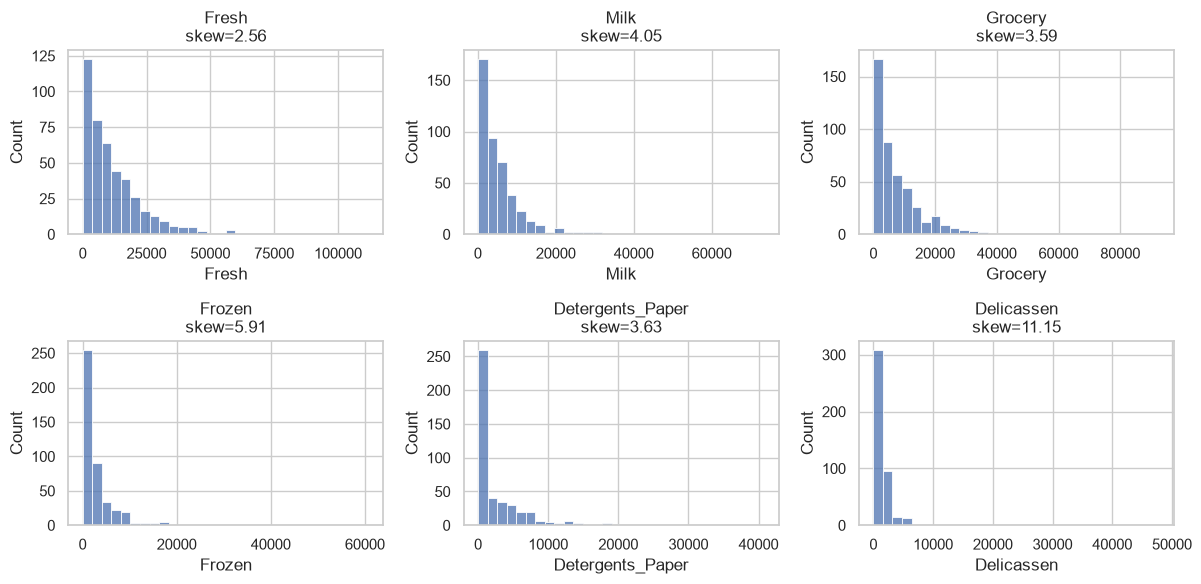

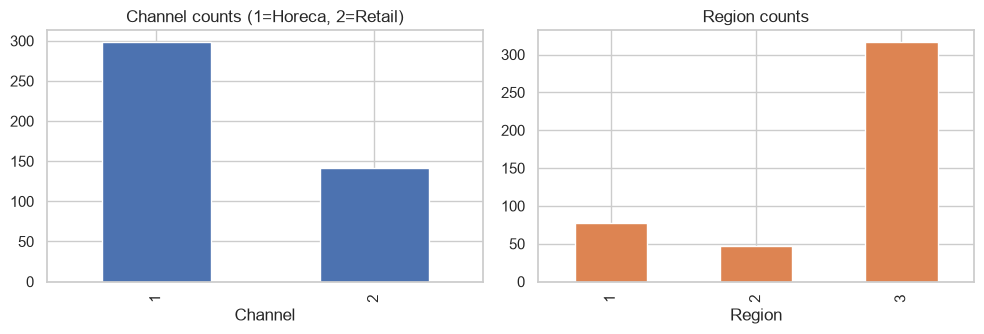

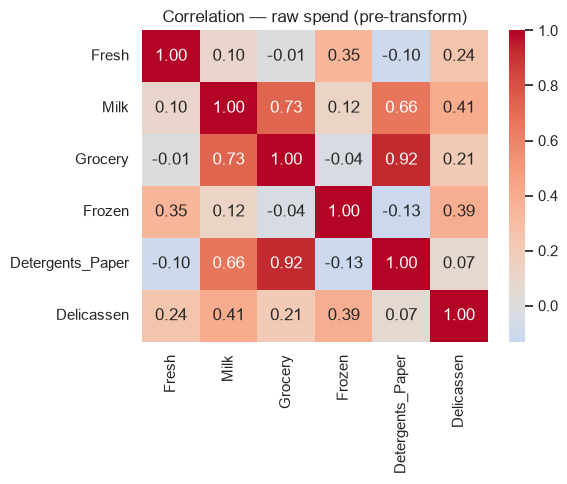

In [3]:
print("Missing values:\n", df.isna().sum())
print("\nDescribe spend:")
display(df[SPEND_COLS].describe())

print("\nMean vs median (skew signal):")
cmp = pd.DataFrame(
    {
        "mean": df[SPEND_COLS].mean(),
        "median": df[SPEND_COLS].median(),
        "skew": df[SPEND_COLS].skew(),
        "mean_over_median": df[SPEND_COLS].mean() / df[SPEND_COLS].median(),
    }
)
display(cmp)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.ravel(), SPEND_COLS):
    sns.histplot(df[col], bins=30, ax=ax)
    ax.set_title(f"{col}\nskew={df[col].skew():.2f}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
df["Channel"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Channel counts (1=Horeca, 2=Retail)")
df["Region"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="C1", title="Region counts")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[SPEND_COLS].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation — raw spend (pre-transform)")
plt.tight_layout()
plt.show()

## 4. Feature engineering

- **Cluster on:** the six spend columns only
- **Hold out:** `Channel`, `Region` for sanity check later
- **Transform:** `log1p` on spends when skew is high (observed above), then
  `StandardScaler`

Skew before log:
Fresh                2.561323
Milk                 4.053755
Grocery              3.587429
Frozen               5.907986
Detergents_Paper     3.631851
Delicassen          11.151586
dtype: float64

Skew after log1p:
Fresh              -1.575326
Milk               -0.224063
Grocery            -0.674938
Frozen             -0.352655
Detergents_Paper   -0.235961
Delicassen         -1.091827
dtype: float64
Scaled means≈0: {'Fresh': 0.0, 'Milk': -0.0, 'Grocery': -0.0, 'Frozen': 0.0, 'Detergents_Paper': -0.0, 'Delicassen': -0.0}


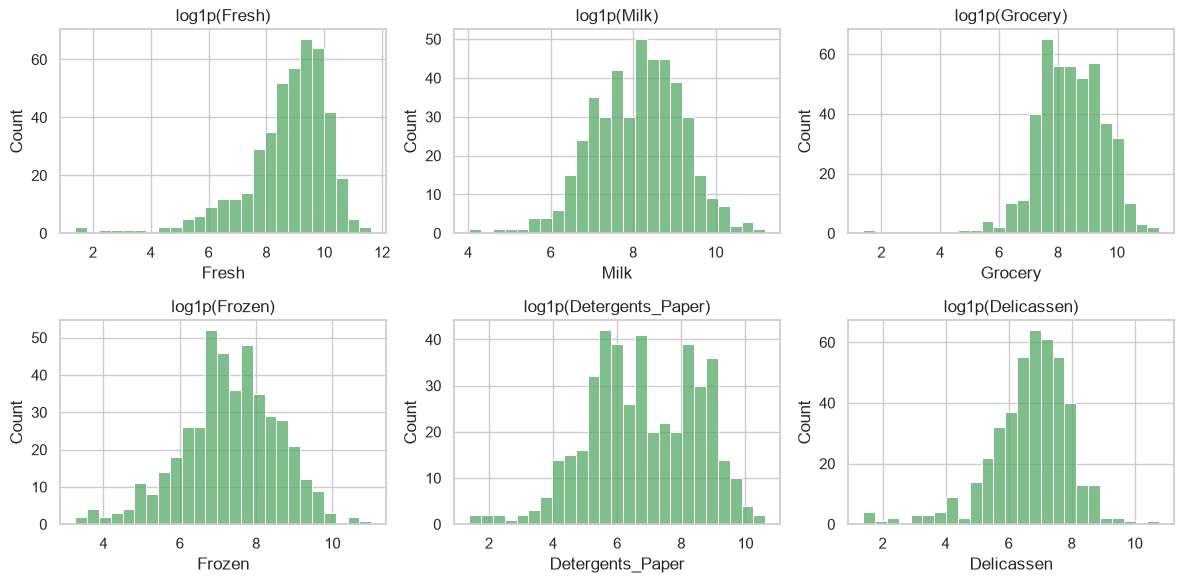

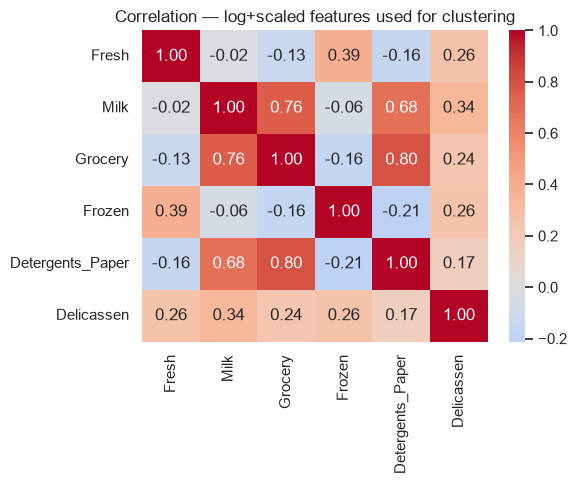

In [4]:
skews = df[SPEND_COLS].skew()
print("Skew before log:")
print(skews)

X_log = df[SPEND_COLS].apply(np.log1p)
print("\nSkew after log1p:")
print(X_log.skew())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled_df = pd.DataFrame(X_scaled, columns=SPEND_COLS, index=df.index)
print("Scaled means≈0:", X_scaled_df.mean().round(4).to_dict())

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.ravel(), SPEND_COLS):
    sns.histplot(X_log[col], bins=25, ax=ax, color="C2")
    ax.set_title(f"log1p({col})")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(X_scaled_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation — log+scaled features used for clustering")
plt.tight_layout()
plt.show()

## 5. Part 1 — PyCaret survey → best 2

In [5]:
from pycaret.clustering import ClusteringExperiment

cluster_df = X_scaled_df.copy()
exp = ClusteringExperiment(session_id=SEED, normalize=False).fit(cluster_df)
available = exp.models()
display(available)
candidate_ids = [m for m in ["kmeans", "hclust", "birch", "dbscan", "optics", "sc", "meanshift", "ap"] if m in available.index]
print("Candidates:", candidate_ids)


def parse_cluster_labels(series: pd.Series) -> np.ndarray:
    s = series.astype(str).str.replace("Cluster ", "", regex=False)
    return pd.to_numeric(s, errors="coerce").fillna(-1).astype(int).to_numpy()


def internal_metrics(X: np.ndarray, labels: np.ndarray) -> dict:
    labels = np.asarray(labels)
    mask = labels >= 0
    n_noise = int((~mask).sum())
    n = int(mask.sum())
    uniq = sorted(set(labels[mask].tolist())) if n else []
    out = {
        "n_clusters": len(uniq),
        "n_noise": n_noise,
        "noise_pct": 100.0 * n_noise / len(labels) if len(labels) else np.nan,
        "largest_cluster_pct": np.nan,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
    }
    if not uniq:
        return out
    sizes = pd.Series(labels[mask]).value_counts()
    out["largest_cluster_pct"] = 100.0 * sizes.iloc[0] / n
    if len(uniq) >= 2 and n > len(uniq):
        out["silhouette"] = float(silhouette_score(X[mask], labels[mask]))
        out["davies_bouldin"] = float(davies_bouldin_score(X[mask], labels[mask]))
        out["calinski_harabasz"] = float(calinski_harabasz_score(X[mask], labels[mask]))
    return out


survey_rows = []
for mid in candidate_ids:
    print(f"\n--- Survey: {mid} ---")
    t1 = time.time()
    try:
        kwargs = {}
        if mid in {"kmeans", "hclust", "birch", "sc"}:
            kwargs["num_clusters"] = 4
        res = exp.create_model(mid, verbose=False, **kwargs)
        labelled = exp.assign_model(res.pipeline)
        y = parse_cluster_labels(labelled["Cluster"])
        m = internal_metrics(X_scaled, y)
        row = {"model": mid, "seconds": round(time.time() - t1, 2), "error": "", **m}
        print(row)
        survey_rows.append(row)
    except Exception as exc:
        survey_rows.append(
            {
                "model": mid,
                "seconds": round(time.time() - t1, 2),
                "error": str(exc),
                "n_clusters": np.nan,
                "n_noise": np.nan,
                "noise_pct": np.nan,
                "largest_cluster_pct": np.nan,
                "silhouette": np.nan,
                "davies_bouldin": np.nan,
                "calinski_harabasz": np.nan,
            }
        )
        print("FAIL", exc)

survey = pd.DataFrame(survey_rows)
print("\n=== Full survey ===")
display(survey.sort_values("silhouette", ascending=False, na_position="last"))

survey["viable"] = (
    (survey["error"].fillna("") == "")
    & survey["silhouette"].notna()
    & (survey["n_clusters"] >= 2)
    & (survey["n_clusters"] <= 25)
    & (survey["noise_pct"] <= 30)
    & (survey["largest_cluster_pct"] <= 85)
)
print("Viability filter (noise≤30%, largest≤85%, 2–25 clusters):")
display(survey[["model", "n_clusters", "noise_pct", "largest_cluster_pct", "silhouette", "viable"]])
rankable = survey.loc[survey["viable"]].copy()


def survey_score(row: pd.Series) -> float:
    if pd.isna(row["silhouette"]):
        return -1e9
    score = float(row["silhouette"])
    if pd.notna(row["calinski_harabasz"]):
        score += 0.0005 * float(row["calinski_harabasz"])
    if pd.notna(row["davies_bouldin"]):
        score -= 0.05 * float(row["davies_bouldin"])
    score -= 0.002 * max(0.0, float(row["largest_cluster_pct"]) - 60.0)
    return score


if len(rankable) < 2:
    print("WARNING: <2 models passed hard filter; relaxing to noise≤50% and largest≤95%")
    rankable = survey.loc[
        (survey["error"].fillna("") == "")
        & survey["silhouette"].notna()
        & (survey["n_clusters"] >= 2)
        & (survey["n_clusters"] <= 50)
        & (survey["noise_pct"] <= 50)
        & (survey["largest_cluster_pct"] <= 95)
    ].copy()

rankable["score"] = rankable.apply(survey_score, axis=1)
rankable = rankable.sort_values("score", ascending=False)
display(rankable)
if len(rankable) < 2:
    raise RuntimeError(survey)
best_two = rankable["model"].head(2).tolist()
print("Best 2 from survey:", best_two)
for i, mid in enumerate(best_two, 1):
    r = rankable.loc[rankable["model"] == mid].iloc[0]
    print(
        f"  #{i} {mid}: Sil={r['silhouette']:.4f}, CH={r['calinski_harabasz']:.1f}, "
        f"DB={r['davies_bouldin']:.4f}, noise%={r['noise_pct']:.1f}, largest%={r['largest_cluster_pct']:.1f}"
    )

,Name,Reference,Turbo
ID,,,
kmeans,K-Means Clustering,sklearn.cluster._kmeans.KMeans,False
ap,Affinity Propagation,sklearn.cluster._affinity_propagation.Affinity...,False
meanshift,Mean Shift Clustering,sklearn.cluster._mean_shift.MeanShift,False
sc,Spectral Clustering,sklearn.cluster._spectral.SpectralClustering,False
hclust,Agglomerative Clustering,sklearn.cluster._agglomerative.AgglomerativeCl...,False
dbscan,Density-Based Spatial Clustering,sklearn.cluster._dbscan.DBSCAN,False
optics,OPTICS Clustering,sklearn.cluster._optics.OPTICS,False
birch,Birch Clustering,sklearn.cluster._birch.Birch,False


Candidates: ['kmeans', 'hclust', 'birch', 'dbscan', 'optics', 'sc', 'meanshift', 'ap']

--- Survey: kmeans ---
{'model': 'kmeans', 'seconds': 0.09, 'error': '', 'n_clusters': 4, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(32.95454545454545), 'silhouette': 0.1851434653334108, 'davies_bouldin': 1.5642939587159899, 'calinski_harabasz': 131.143037926091}

--- Survey: hclust ---
{'model': 'hclust', 'seconds': 0.07, 'error': '', 'n_clusters': 4, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(47.27272727272727), 'silhouette': 0.2020795686473931, 'davies_bouldin': 1.5210907132699092, 'calinski_harabasz': 108.60672962333317}

--- Survey: birch ---


{'model': 'birch', 'seconds': 0.11, 'error': '', 'n_clusters': 4, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(46.59090909090909), 'silhouette': 0.2197224864629374, 'davies_bouldin': 1.4156552340075064, 'calinski_harabasz': 109.43650953455135}

--- Survey: dbscan ---
{'model': 'dbscan', 'seconds': 0.06, 'error': '', 'n_clusters': 1, 'n_noise': 435, 'noise_pct': 98.86363636363636, 'largest_cluster_pct': np.float64(100.0), 'silhouette': nan, 'davies_bouldin': nan, 'calinski_harabasz': nan}

--- Survey: optics ---


{'model': 'optics', 'seconds': 7.22, 'error': '', 'n_clusters': 6, 'n_noise': 392, 'noise_pct': 89.0909090909091, 'largest_cluster_pct': np.float64(20.833333333333332), 'silhouette': 0.49701954279207694, 'davies_bouldin': 0.7207104522673758, 'calinski_harabasz': 107.71799406587883}

--- Survey: sc ---


{'model': 'sc', 'seconds': 0.79, 'error': '', 'n_clusters': 4, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(97.95454545454545), 'silhouette': 0.35905901041799604, 'davies_bouldin': 1.6392139498748381, 'calinski_harabasz': 12.76912781264521}

--- Survey: meanshift ---


...

,model,seconds,error,n_clusters,n_noise,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz
4,optics,7.22,,6,392,89.090909,20.833333,0.497020,0.720710,107.717994
5,sc,0.79,,4,0,0.000000,97.954545,0.359059,1.639214,12.769128
6,meanshift,5.64,,5,0,0.000000,96.136364,0.352807,1.069313,17.191477
2,birch,0.11,,4,0,0.000000,46.590909,0.219722,1.415655,109.436510
1,hclust,0.07,,4,0,0.000000,47.272727,0.202080,1.521091,108.606730
0,kmeans,0.09,,4,0,0.000000,32.954545,0.185143,1.564294,131.143038
7,ap,0.24,,38,0,0.000000,6.818182,0.147886,1.186514,50.467146
3,dbscan,0.06,,1,435,98.863636,100.000000,NaN,NaN,NaN


Viability filter (noise≤30%, largest≤85%, 2–25 clusters):


,model,n_clusters,noise_pct,largest_cluster_pct,silhouette,viable
0,kmeans,4,0.000000,32.954545,0.185143,True
1,hclust,4,0.000000,47.272727,0.202080,True
2,birch,4,0.000000,46.590909,0.219722,True
3,dbscan,1,98.863636,100.000000,NaN,False
4,optics,6,89.090909,20.833333,0.497020,False
5,sc,4,0.000000,97.954545,0.359059,False
6,meanshift,5,0.000000,96.136364,0.352807,False
7,ap,38,0.000000,6.818182,0.147886,False


,model,seconds,error,n_clusters,n_noise,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,viable,score
2,birch,0.11,,4,0,0.0,46.590909,0.219722,1.415655,109.436510,True,0.203658
1,hclust,0.07,,4,0,0.0,47.272727,0.202080,1.521091,108.606730,True,0.180328
0,kmeans,0.09,,4,0,0.0,32.954545,0.185143,1.564294,131.143038,True,0.172500


Best 2 from survey: ['birch', 'hclust']
  #1 birch: Sil=0.2197, CH=109.4, DB=1.4157, noise%=0.0, largest%=46.6
  #2 hclust: Sil=0.2021, CH=108.6, DB=1.5211, noise%=0.0, largest%=47.3


## 6. Part 2 — Proper scikit-learn re-implementation of the best 2


Proper sklearn: birch → birch


,k,inertia,n_clusters,n_noise,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz
0,2,NaN,2,0,0.0,53.409091,0.221896,1.644555,123.536318
1,3,NaN,3,0,0.0,46.590909,0.215652,1.517205,122.451482
2,4,NaN,4,0,0.0,46.590909,0.219722,1.415655,109.436510
3,5,NaN,5,0,0.0,46.590909,0.208955,1.376885,97.221840
4,6,NaN,6,0,0.0,33.863636,0.144832,1.593752,89.470362
5,7,NaN,7,0,0.0,33.863636,0.141300,1.576234,86.372368
6,8,NaN,8,0,0.0,33.863636,0.147772,1.519101,79.957809
7,9,NaN,9,0,0.0,22.500000,0.150407,1.573427,77.899698
8,10,NaN,10,0,0.0,22.500000,0.153621,1.486613,74.527330


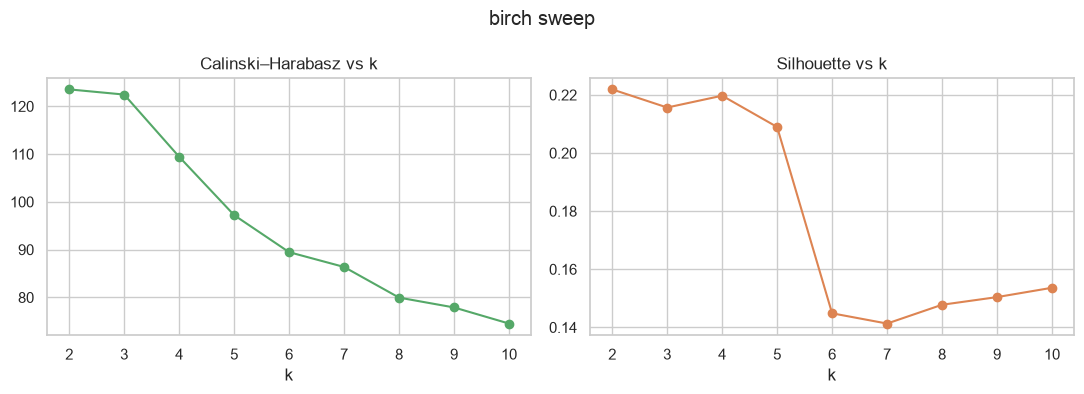

Chosen k=2
Final metrics: {'n_clusters': 2, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(53.40909090909091), 'silhouette': 0.22189580432668296, 'davies_bouldin': 1.6445548011125661, 'calinski_harabasz': 123.53631841224141}
Params: {'n_clusters': 2}


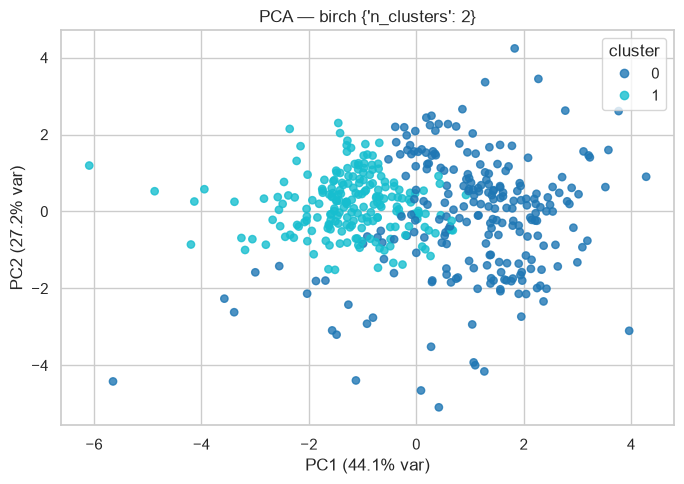

Profiles (original spend units):


,cluster,n_customers,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,mean_total_spend,total_spend,pct_customers,pct_spend
0,0,235,12123.931915,8765.327660,12552.012766,2845.565957,5001.527660,1979.110638,43267.476596,10167857,53.409091,69.549964
1,1,205,11858.570732,2392.707317,2677.263415,3331.424390,451.209756,1004.156098,21715.331707,4451643,46.590909,30.450036



Proper sklearn: hclust → hclust


,k,inertia,n_clusters,n_noise,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz
0,2,NaN,2,0,0.0,59.545455,0.258495,1.600363,134.624461
1,3,NaN,3,0,0.0,59.545455,0.254657,1.538995,116.799278
2,4,NaN,4,0,0.0,47.272727,0.202080,1.521091,108.606730
3,5,NaN,5,0,0.0,47.272727,0.202547,1.386198,100.014606
4,6,NaN,6,0,0.0,34.090909,0.170707,1.489516,94.856575
5,7,NaN,7,0,0.0,34.090909,0.163338,1.498277,91.300533
6,8,NaN,8,0,0.0,24.545455,0.148217,1.586505,86.612453
7,9,NaN,9,0,0.0,24.545455,0.155490,1.549174,82.006448
8,10,NaN,10,0,0.0,24.545455,0.121827,1.501191,77.714516


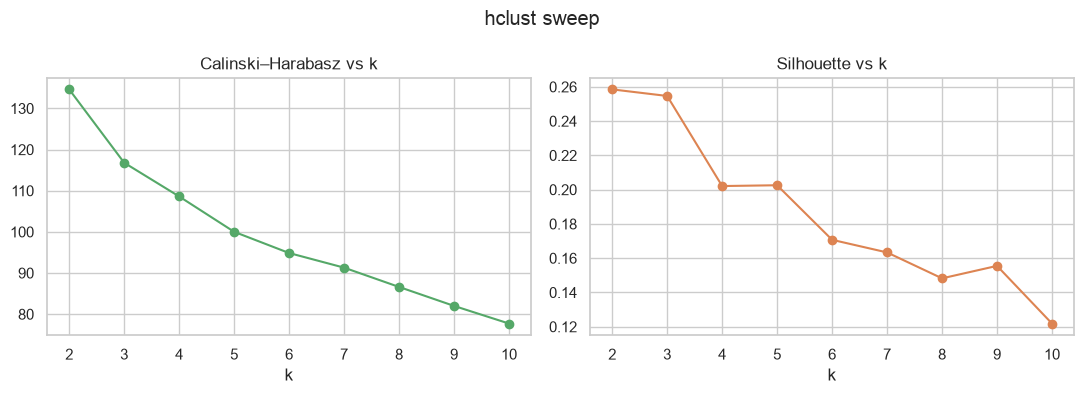

Chosen k=2
Final metrics: {'n_clusters': 2, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(59.54545454545455), 'silhouette': 0.25849531748001764, 'davies_bouldin': 1.6003633212363932, 'calinski_harabasz': 134.62446054306855}
Params: {'n_clusters': 2}


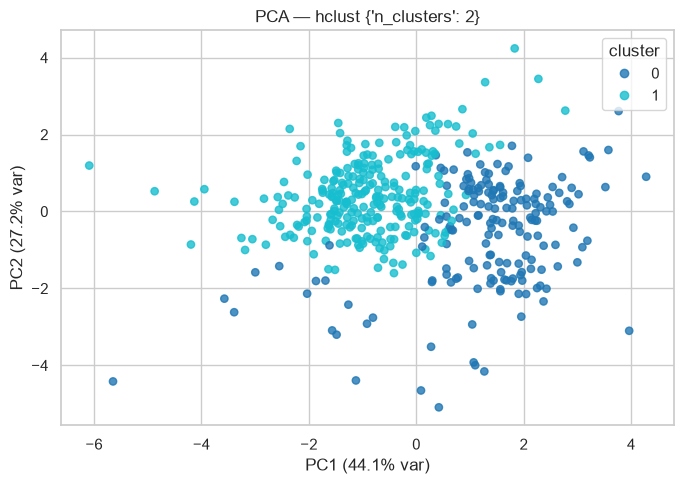

Profiles (original spend units):


,cluster,n_customers,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,mean_total_spend,total_spend,pct_customers,pct_spend
0,0,178,7561.308989,9338.168539,14247.112360,1429.398876,6214.910112,1483.831461,40274.730337,7168902,40.454545,49.036574
1,1,262,15016.099237,3389.935115,3673.954198,4187.851145,616.805344,1552.751908,28437.396947,7450598,59.545455,50.963426


In [6]:
ALGO_MAP = {
    "kmeans": "kmeans",
    "hclust": "hclust",
    "birch": "birch",
    "sc": "sc",
    "dbscan": "dbscan",
    "optics": "optics",
    "meanshift": "meanshift",
    "ap": "ap",
}


def fit_sklearn(algo: str, X: np.ndarray, **params):
    if algo == "kmeans":
        return KMeans(n_clusters=params.get("n_clusters", 4), random_state=SEED, n_init=10).fit(X)
    if algo == "hclust":
        return AgglomerativeClustering(n_clusters=params.get("n_clusters", 4)).fit(X)
    if algo == "birch":
        return Birch(n_clusters=params.get("n_clusters", 4)).fit(X)
    if algo == "sc":
        return SpectralClustering(
            n_clusters=params.get("n_clusters", 4),
            random_state=SEED,
            assign_labels="kmeans",
            affinity="nearest_neighbors",
            n_neighbors=min(15, max(2, len(X) // 20)),
        ).fit(X)
    if algo == "dbscan":
        return DBSCAN(eps=params.get("eps", 0.8), min_samples=params.get("min_samples", 5)).fit(X)
    if algo == "optics":
        return OPTICS(min_samples=params.get("min_samples", 5), xi=params.get("xi", 0.05)).fit(X)
    if algo == "meanshift":
        bw = params.get("bandwidth")
        if bw is None:
            bw = estimate_bandwidth(X, quantile=0.2, n_samples=min(500, len(X)), random_state=SEED)
            if not np.isfinite(bw) or bw <= 0:
                bw = 1.0
        return MeanShift(bandwidth=bw, bin_seeding=True).fit(X)
    if algo == "ap":
        return AffinityPropagation(random_state=SEED, damping=params.get("damping", 0.9)).fit(X)
    raise ValueError(algo)


def labels_from_model(model) -> np.ndarray:
    return np.asarray(model.labels_)


def sweep_k(algo: str, X: np.ndarray, ks=range(2, 11)):
    rows = []
    for k in ks:
        model = fit_sklearn(algo, X, n_clusters=k)
        y = labels_from_model(model)
        m = internal_metrics(X, y)
        rows.append({"k": k, "inertia": getattr(model, "inertia_", np.nan), **m})
    return pd.DataFrame(rows)


def profile_clusters(frame: pd.DataFrame, labels: np.ndarray, spend_cols: list[str]) -> pd.DataFrame:
    tmp = frame.copy()
    tmp["cluster"] = labels
    tmp["row_spend"] = tmp[spend_cols].sum(axis=1)
    g = tmp.groupby("cluster")
    prof = g[spend_cols].mean()
    prof.insert(0, "n_customers", g.size())
    prof["mean_total_spend"] = g["row_spend"].mean()
    prof["total_spend"] = g["row_spend"].sum()
    prof = prof.reset_index()
    prof["pct_customers"] = 100 * prof["n_customers"] / prof["n_customers"].sum()
    prof["pct_spend"] = 100 * prof["total_spend"] / prof["total_spend"].sum()
    return prof.sort_values("mean_total_spend", ascending=False)


def pca_scatter(X: np.ndarray, labels: np.ndarray, title: str):
    pca = PCA(n_components=2, random_state=SEED)
    Z = pca.fit_transform(X)
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap="tab10", s=28, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)")
    ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)")
    ax.legend(*sc.legend_elements(), title="cluster")
    plt.tight_layout()
    plt.show()


proper_results = {}
for mid in best_two:
    algo = ALGO_MAP[mid]
    print("\n" + "=" * 70)
    print(f"Proper sklearn: {mid} → {algo}")
    print("=" * 70)

    if algo in {"kmeans", "hclust", "birch", "sc"}:
        sweep = sweep_k(algo, X_scaled)
        display(sweep)
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        if algo == "kmeans" and sweep["inertia"].notna().any():
            axes[0].plot(sweep["k"], sweep["inertia"], marker="o")
            axes[0].set_title("Elbow (inertia)")
        else:
            axes[0].plot(sweep["k"], sweep["calinski_harabasz"], marker="o", color="C2")
            axes[0].set_title("Calinski–Harabasz vs k")
        axes[1].plot(sweep["k"], sweep["silhouette"], marker="o", color="C1")
        axes[1].set_title("Silhouette vs k")
        for ax in axes:
            ax.set_xlabel("k")
        plt.suptitle(f"{algo} sweep")
        plt.tight_layout()
        plt.show()
        viable = sweep.loc[sweep["largest_cluster_pct"] < 92].copy()
        if viable.empty:
            viable = sweep
        best_row = viable.sort_values(["silhouette", "calinski_harabasz"], ascending=[False, False]).iloc[0]
        best_k = int(best_row["k"])
        print(f"Chosen k={best_k}")
        model = fit_sklearn(algo, X_scaled, n_clusters=best_k)
        y = labels_from_model(model)
        params_used = {"n_clusters": best_k}
        sweep_table = sweep

    elif algo == "dbscan":
        nn = NearestNeighbors(n_neighbors=5).fit(X_scaled)
        dists, _ = nn.kneighbors(X_scaled)
        kth = np.sort(dists[:, -1])
        candidates = sorted(set(np.round(np.quantile(kth, [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]), 3).tolist()))
        rows = []
        for eps in candidates:
            for ms in [3, 5, 8]:
                model = fit_sklearn("dbscan", X_scaled, eps=eps, min_samples=ms)
                y_try = labels_from_model(model)
                m = internal_metrics(X_scaled, y_try)
                rows.append({"eps": eps, "min_samples": ms, **m})
        sweep = pd.DataFrame(rows)
        display(sweep.sort_values("silhouette", ascending=False).head(12))
        fig, ax = plt.subplots(figsize=(8, 3.5))
        ax.plot(kth)
        ax.set_title("k-distance plot")
        plt.tight_layout()
        plt.show()
        viable = sweep.loc[(sweep["n_clusters"] >= 2) & (sweep["noise_pct"] <= 40)].copy()
        if viable.empty:
            viable = sweep.loc[sweep["n_clusters"] >= 2]
        best_row = viable.sort_values("silhouette", ascending=False).iloc[0]
        params_used = {"eps": float(best_row["eps"]), "min_samples": int(best_row["min_samples"])}
        model = fit_sklearn("dbscan", X_scaled, **params_used)
        y = labels_from_model(model)
        sweep_table = sweep

    elif algo == "optics":
        rows = []
        for ms in [3, 5, 8, 10]:
            for xi in [0.03, 0.05, 0.1]:
                model = fit_sklearn("optics", X_scaled, min_samples=ms, xi=xi)
                m = internal_metrics(X_scaled, labels_from_model(model))
                rows.append({"min_samples": ms, "xi": xi, **m})
        sweep = pd.DataFrame(rows)
        display(sweep.sort_values("silhouette", ascending=False).head(12))
        viable = sweep.loc[(sweep["n_clusters"] >= 2) & (sweep["noise_pct"] <= 40)]
        if viable.empty:
            viable = sweep.loc[sweep["n_clusters"] >= 2]
        best_row = viable.sort_values("silhouette", ascending=False).iloc[0]
        params_used = {"min_samples": int(best_row["min_samples"]), "xi": float(best_row["xi"])}
        model = fit_sklearn("optics", X_scaled, **params_used)
        y = labels_from_model(model)
        sweep_table = sweep

    elif algo == "meanshift":
        rows = []
        for q in [0.1, 0.15, 0.2, 0.25, 0.3]:
            bw = estimate_bandwidth(X_scaled, quantile=q, n_samples=min(500, len(X_scaled)), random_state=SEED)
            if not np.isfinite(bw) or bw <= 0:
                continue
            model = fit_sklearn("meanshift", X_scaled, bandwidth=bw)
            m = internal_metrics(X_scaled, labels_from_model(model))
            rows.append({"quantile": q, "bandwidth": bw, **m})
        sweep = pd.DataFrame(rows)
        display(sweep)
        best_row = sweep.loc[sweep["n_clusters"] >= 2].sort_values("silhouette", ascending=False).iloc[0]
        params_used = {"bandwidth": float(best_row["bandwidth"]), "quantile": float(best_row["quantile"])}
        model = fit_sklearn("meanshift", X_scaled, bandwidth=params_used["bandwidth"])
        y = labels_from_model(model)
        sweep_table = sweep

    elif algo == "ap":
        rows = []
        for damp in [0.5, 0.7, 0.9]:
            model = fit_sklearn("ap", X_scaled, damping=damp)
            m = internal_metrics(X_scaled, labels_from_model(model))
            rows.append({"damping": damp, **m})
        sweep = pd.DataFrame(rows)
        display(sweep)
        best_row = sweep.sort_values("silhouette", ascending=False).iloc[0]
        params_used = {"damping": float(best_row["damping"])}
        model = fit_sklearn("ap", X_scaled, **params_used)
        y = labels_from_model(model)
        sweep_table = sweep
    else:
        raise ValueError(algo)

    metrics = internal_metrics(X_scaled, y)
    print("Final metrics:", metrics)
    print("Params:", params_used)
    pca_scatter(X_scaled, y, f"PCA — {algo} {params_used}")
    prof = profile_clusters(df, y, SPEND_COLS)
    print("Profiles (original spend units):")
    display(prof)
    proper_results[mid] = {
        "algo": algo,
        "params": params_used,
        "labels": y,
        "metrics": metrics,
        "profile": prof,
        "sweep": sweep_table,
    }

## 7. Side-by-side comparison

In [7]:
cmp_rows = []
for mid, res in proper_results.items():
    m = res["metrics"]
    cmp_rows.append(
        {
            "model": mid,
            "algo": res["algo"],
            "params": res["params"],
            "n_clusters": m["n_clusters"],
            "noise_pct": m["noise_pct"],
            "largest_cluster_pct": m["largest_cluster_pct"],
            "silhouette": m["silhouette"],
            "davies_bouldin": m["davies_bouldin"],
            "calinski_harabasz": m["calinski_harabasz"],
        }
    )
comparison = pd.DataFrame(cmp_rows)
display(comparison)

for mid, res in proper_results.items():
    print(f"\n{mid}: clusters={res['metrics']['n_clusters']}, "
          f"largest={res['metrics']['largest_cluster_pct']:.1f}%, noise={res['metrics']['noise_pct']:.1f}%")
    display(res["profile"].loc[res["profile"]["cluster"] >= 0])


def business_score(row) -> float:
    s = 0.0 if pd.isna(row["silhouette"]) else float(row["silhouette"])
    if row["noise_pct"] > 30:
        s -= 0.3
    if row["largest_cluster_pct"] > 85:
        s -= 0.2
    return s


comparison["business_score"] = comparison.apply(business_score, axis=1)
preferred = comparison.sort_values("business_score", ascending=False).iloc[0]
print("Preferred:", preferred["model"], preferred["params"], f"Sil={preferred['silhouette']:.4f}")

,model,algo,params,n_clusters,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz
0,birch,birch,{'n_clusters': 2},2,0.0,53.409091,0.221896,1.644555,123.536318
1,hclust,hclust,{'n_clusters': 2},2,0.0,59.545455,0.258495,1.600363,134.624461



birch: clusters=2, largest=53.4%, noise=0.0%


,cluster,n_customers,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,mean_total_spend,total_spend,pct_customers,pct_spend
0,0,235,12123.931915,8765.327660,12552.012766,2845.565957,5001.527660,1979.110638,43267.476596,10167857,53.409091,69.549964
1,1,205,11858.570732,2392.707317,2677.263415,3331.424390,451.209756,1004.156098,21715.331707,4451643,46.590909,30.450036



hclust: clusters=2, largest=59.5%, noise=0.0%


,cluster,n_customers,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,mean_total_spend,total_spend,pct_customers,pct_spend
0,0,178,7561.308989,9338.168539,14247.112360,1429.398876,6214.910112,1483.831461,40274.730337,7168902,40.454545,49.036574
1,1,262,15016.099237,3389.935115,3673.954198,4187.851145,616.805344,1552.751908,28437.396947,7450598,59.545455,50.963426


Preferred: hclust {'n_clusters': 2} Sil=0.2585


## 8. External sanity check — `Channel` / `Region`

These columns were **not** fed into clustering. Crosstabs only ask: did the
unsupervised spend-based segments recover any of the known business structure?
Agreement here is interesting but **not** “accuracy.”

In [8]:
pref_mid = preferred["model"]
pref_labels = proper_results[pref_mid]["labels"]
sanity = df[HOLD_OUT].copy()
sanity["cluster"] = pref_labels

print(f"Sanity check model: {pref_mid}")
print("\nCluster × Channel (counts):")
ct_ch = pd.crosstab(sanity["cluster"], sanity["Channel"], margins=True)
display(ct_ch)
print("\nCluster × Channel (row %):")
display(pd.crosstab(sanity["cluster"], sanity["Channel"], normalize="index").mul(100).round(1))

print("\nCluster × Region (counts):")
ct_rg = pd.crosstab(sanity["cluster"], sanity["Region"], margins=True)
display(ct_rg)
print("\nCluster × Region (row %):")
display(pd.crosstab(sanity["cluster"], sanity["Region"], normalize="index").mul(100).round(1))

# Simple association summary without calling it validation accuracy
for cl in sorted(set(pref_labels)):
    if cl < 0:
        continue
    sub = sanity.loc[sanity["cluster"] == cl]
    ch_mode = sub["Channel"].value_counts(normalize=True).iloc[0] * 100
    ch_name = sub["Channel"].value_counts().index[0]
    print(
        f"Cluster {cl}: n={len(sub)}, dominant Channel={ch_name} "
        f"({ch_mode:.1f}% of cluster) — descriptive only"
    )

Sanity check model: hclust

Cluster × Channel (counts):


Channel,1,2,All
cluster,,,
0,47,131,178
1,251,11,262
All,298,142,440



Cluster × Channel (row %):


Channel,1,2
cluster,,
0,26.4,73.6
1,95.8,4.2



Cluster × Region (counts):


Region,1,2,3,All
cluster,,,,
0,26,20,132,178
1,51,27,184,262
All,77,47,316,440



Cluster × Region (row %):


Region,1,2,3
cluster,,,
0,14.6,11.2,74.2
1,19.5,10.3,70.2


Cluster 0: n=178, dominant Channel=2 (73.6% of cluster) — descriptive only
Cluster 1: n=262, dominant Channel=1 (95.8% of cluster) — descriptive only


## 9. Explaining this to your manager

In [9]:
pref = proper_results[pref_mid]
prof = pref["profile"].loc[pref["profile"]["cluster"] >= 0].sort_values(
    "mean_total_spend", ascending=False
).reset_index(drop=True)

print("MANAGER BRIEF — Wholesale Customers segments")
print("=" * 60)
print(
    f"We clustered {len(df)} wholesale accounts into {pref['metrics']['n_clusters']} "
    f"segments with {pref['algo']} {pref['params']} using only annual category spend "
    f"(log-transformed). Channel/Region were held out."
)
print(
    f"Internal fit: Silhouette={pref['metrics']['silhouette']:.3f}, "
    f"DB={pref['metrics']['davies_bouldin']:.3f}, "
    f"CH={pref['metrics']['calinski_harabasz']:.1f}."
)
print()

actions = [
    "High-spend multi-category: priority account management and volume contracts.",
    "Fresh-heavy: cold-chain SLAs and fresh promotions; protect fill rates.",
    "Grocery/detergents-heavy (often more Retail-like): packaged promo calendars.",
    "Low overall spend: low-cost digital nurture; avoid over-servicing.",
    "Frozen-skewed: capacity planning with warehouse and route density.",
]

for i, row in prof.iterrows():
    top_cat = max(SPEND_COLS, key=lambda c: row[c])
    action = actions[min(i, len(actions) - 1)]
    print(
        f"Segment {int(row['cluster'])}: n={int(row['n_customers'])} "
        f"({row['pct_customers']:.1f}% accounts, {row['pct_spend']:.1f}% spend). "
        f"Mean total≈{row['mean_total_spend']:.0f}; strongest category mean: {top_cat}={row[top_cat]:.0f}."
    )
    print(f"  → Action: {action}")

print(
    "\nSanity note: compare clusters to Channel/Region crosstabs above — any alignment "
    "is a bonus insight, not a quality score. Next step: test offers by segment in-market."
)

MANAGER BRIEF — Wholesale Customers segments
We clustered 440 wholesale accounts into 2 segments with hclust {'n_clusters': 2} using only annual category spend (log-transformed). Channel/Region were held out.
Internal fit: Silhouette=0.258, DB=1.600, CH=134.6.

Segment 0: n=178 (40.5% accounts, 49.0% spend). Mean total≈40275; strongest category mean: Grocery=14247.
  → Action: High-spend multi-category: priority account management and volume contracts.
Segment 1: n=262 (59.5% accounts, 51.0% spend). Mean total≈28437; strongest category mean: Fresh=15016.
  → Action: Fresh-heavy: cold-chain SLAs and fresh promotions; protect fill rates.

Sanity note: compare clusters to Channel/Region crosstabs above — any alignment is a bonus insight, not a quality score. Next step: test offers by segment in-market.


## 10. What we did not claim

- No classification accuracy on Channel/Region.
- PyCaret surveyed algorithms; **sklearn** re-implementation with sweeps is the deliverable.
- Internal metrics measure geometry, not revenue lift.